
Вы — аналитик данных, и сейчас идёте в стартап, который создает новый маркетплейс. Он недавно появился на рынке и занимается продажей новых товаров из Бразилии, которые только начинают поступать в продажу.

Продакт-менеджер Петя переживает за свой продукт, так как выручка маркетплейса стоит на месте уже несколько месяцев. Он предложил вам полную свободу действий. Главное — чтобы метрики росли, а мы не причиняли неудобства клиентам, ведь Петя заботится об их опыте.

Задачи
Вы поразмышляли и сформулировали список задач:

***Задача 1**: Оценить месячный retention в оформление заказа с помощью когортного анализа.*

***Задача 2**: Определить, существует ли product/market fit у этого маркетплейса.*

***Задача 3**: Определить 5 основных метрик, на которых продакту можно сконцентрироваться, чтобы максимизировать прибыль компании.*

***Задача 4**: Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.*

***Задача 5**: Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.*


***Задача 6**: Сформулировать выводы о проделанной работе и составить отчет.*


Датасет
Файлы:

**olist_customers_dataset.csv** — таблица с уникальными идентификаторами пользователей

**customer_id** — позаказный идентификатор пользователя

**customer_unique_id** — уникальный идентификатор пользователя (аналог номера паспорта)

**customer_zip_code_prefix** — почтовый индекс пользователя

**customer_city** — город доставки пользователя

**customer_state** — штат доставки пользователя

**olist_orders_dataset**.csv —  таблица заказов

**order_id** — уникальный идентификатор заказа (номер чека)

**customer_id** — позаказный идентификатор пользователя

**order_status** — статус заказа

**order_purchase_timestamp** — время создания заказа

**order_approved_at** — время подтверждения оплаты заказа

order_delivered_carrier_date — время передачи заказа в логистическую службу

order_delivered_customer_date — время доставки заказа

order_estimated_delivery_date — обещанная дата доставки

olist_order_items_dataset.csv — товарные позиции, входящие в заказы
order_id — уникальный идентификатор заказа (номер чека)

order_item_id — идентификатор товара внутри одного заказа

product_id — ид товара (аналог штрихкода)

seller_id — ид производителя товара

shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

price — цена за единицу товара

freight_value — вес товара 

Пример структуры данных можно визуализировать по order_id == 00143d0f86d6fbd9f9b38ab440ac16f5

Уникальные статусы заказов в таблице olist_orders_dataset:

created — создан;

approved — подтверждён;

invoiced — выставлен счёт;

processing — в процессе сборки заказа;

shipped — отгружён со склада;

delivered — доставлен пользователю;

unavailable — заказ отменён по причине недоступности товара;

canceled — отменён.

In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
#Читаем файлы
olist_customers = pd.read_csv('data/olist_customers_dataset.csv')
olist_orders = pd.read_csv('data/olist_orders_dataset.csv')
olist_order_items = pd.read_csv('data/olist_order_items_dataset.csv')

### **Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.**

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

**Для этого вам нужно:**

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

**В рамках исследования необходимо:**

Исследовать датасет и определить, какой вид заказа будет учитываться в retention
Построить месячный retention
Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
Найти когорту с самым высоким retention на 3-й месяц.
Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

In [3]:
# Обьедеяем таблицу с заказами и информацией о пользователях
df_full = olist_customers.merge(olist_orders, on='customer_id', how='inner')
# Для анализа выбираем заказы только со статусом delivered
delivered_orders = df_full[(df_full.order_status == 'delivered')]
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])
# 
# delivered_orders = delivered_orders.groupby('customer_unique_id').filter(lambda x: x['order_id'].nunique() > 1)


C:\Users\user\AppData\Local\Temp\ipykernel_18252\1314820507.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])


In [4]:
# Находим месяц первого заказа
first_order = delivered_orders.groupby('customer_unique_id', as_index=False).order_purchase_timestamp.min()
first_order['order_purchase_timestamp'] = first_order['order_purchase_timestamp'].dt.to_period('M')
first_order = first_order.rename(columns={'order_purchase_timestamp':'cohort'}) # переименовываем столбец с когортой
# Добавляем столбец с когортой в основной датафрейм
delivered_orders = delivered_orders.merge(first_order, on='customer_unique_id', how='inner')
# Находим текущий месяц покупки
delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')
# Находим разницу между текущим месяцем и месяцем первой покупки
delivered_orders['cohort_index'] = (delivered_orders['order_month'] - delivered_orders['cohort']).apply(lambda x: x.n)


In [5]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = delivered_orders.groupby(['cohort', 'cohort_index']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()
# Строим retention табалицу
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='cohort_index', values='n_customers')

In [6]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]
# Вычисляем коэффициенты удержания, деля на размер когорты
retention = cohort_pivot.divide(cohort_size, axis=0)

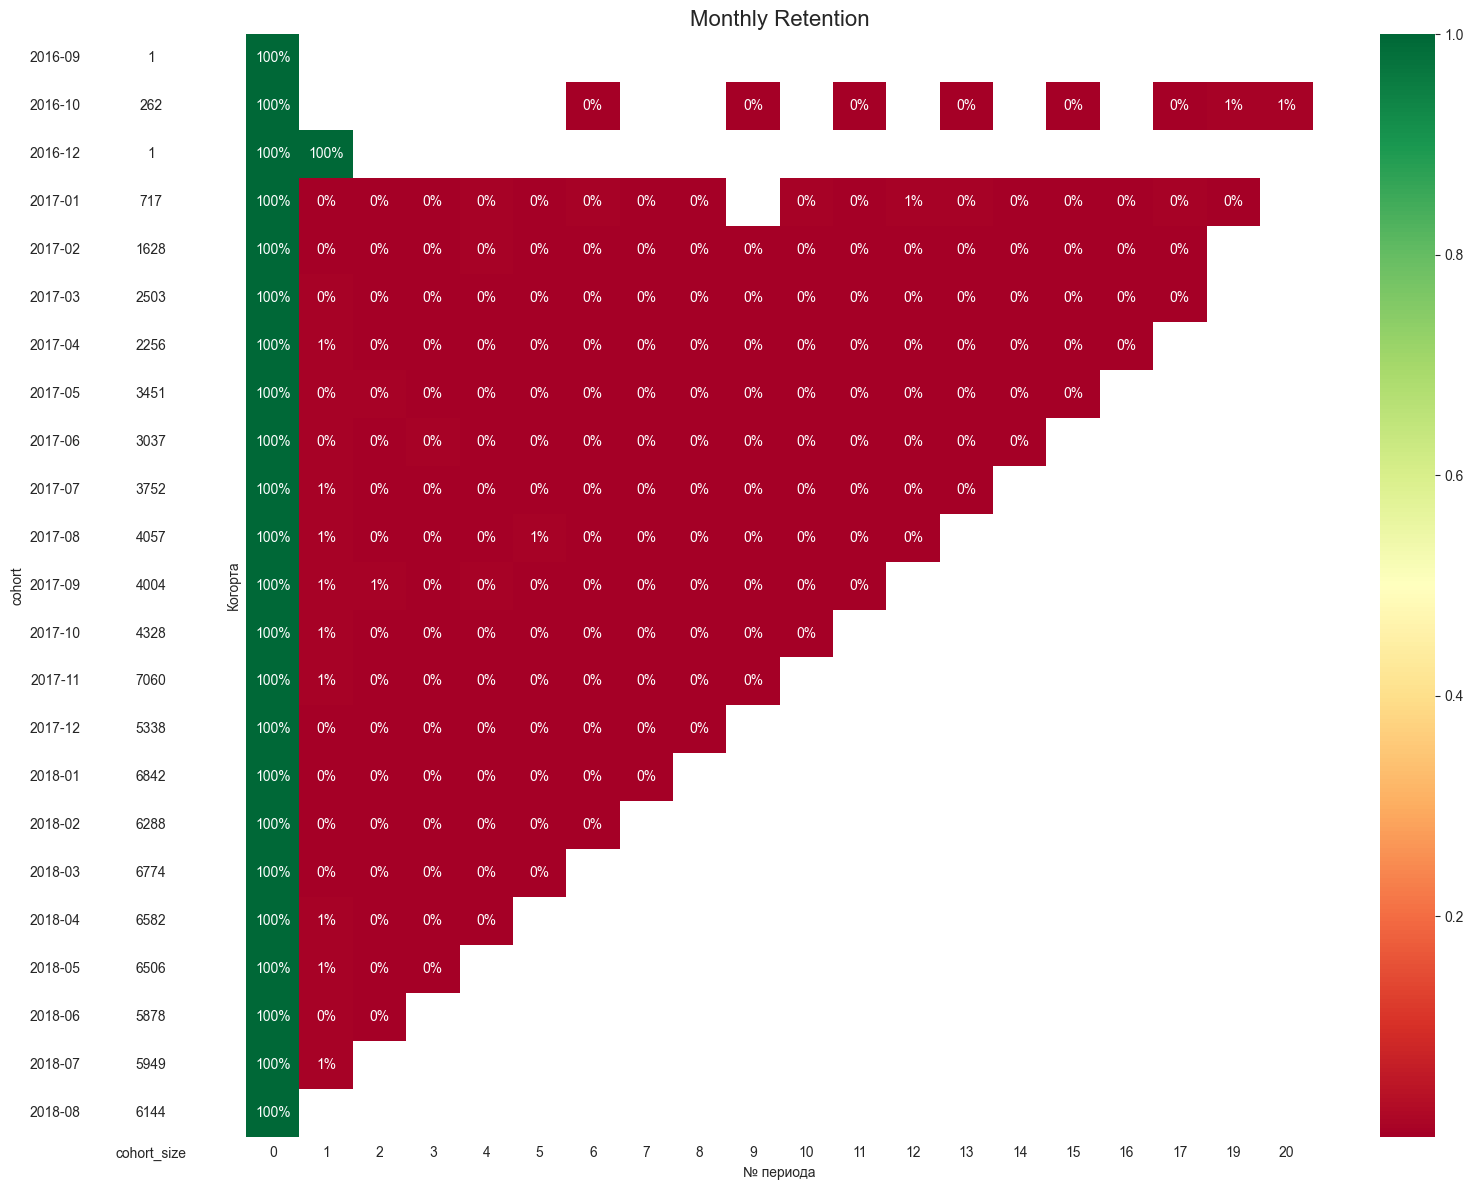

In [7]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention,
                mask=retention.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

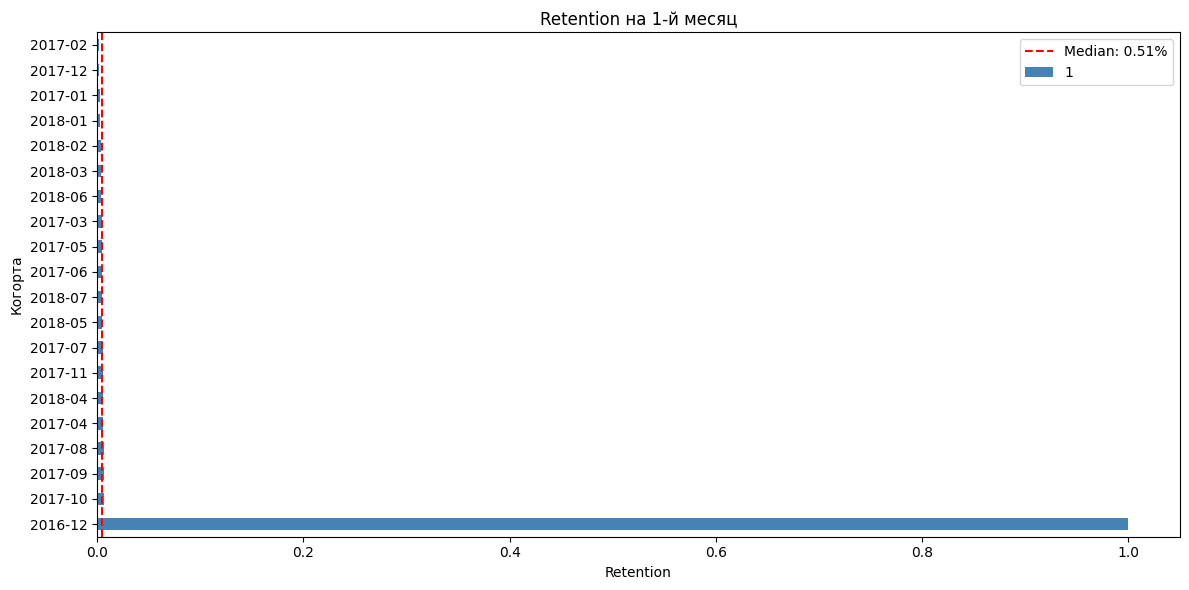

Медианный retention 1-го месяца равен: 0.0051


In [ ]:
# Считаем медиану 1-го месяца retention
retention_month_1 = retention[1].dropna()
median_retention_month_1 = retention_month_1.median()
# Строим график retention на 1-й месяца 
plt.figure(figsize=(12, 6))
retention[1].dropna().sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.axvline(retention[1].median(), color='red', linestyle='--', label=f'Median: {retention[1].median():.2%}')
plt.title('Retention на 1-й месяц')
plt.xlabel('Retention')
plt.ylabel('Когорта')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Медианный retention 1-го месяца равен: {median_retention_month_1:.2}')

In [9]:
# Ищем когорту с самым высоким retention на 3-й месяц.
retention_month_3 = retention[3].dropna()
best_cohort = retention_month_3.idxmax()
best_value = retention_month_3.max()
print(f'Когорта с самым высоким retention на 3-й месяц: {best_cohort}, retention: {best_value:.2}')

Когорта с самым высоким retention на 3-й месяц: 2017-06, retention: 0.0043


### **Задача 2. Определить, существует ли product/market fit у маркетплейса.**

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно:

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

 - Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
 - Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
 - Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

На основании когортного анализа видно, что основная доля пользователей совершают единственную покупку и не возвращаются в продукт. Retention в 1-й месяц медианный составляет ~0.005%, а в 3-й — не превышает 0.0043%. Это говорит о недостаточном уровне PMF. Маркетплейс пока не удерживает пользователей после первой покупки.

Рекомендуется сосредоточиться на улучшении пользовательского опыта после первой покупки, работе с отзывами и повторным вовлечением клиентов. Возможна также сегментация по регионам или каналам привлечения для выявления "живых" сегментов с высоким retention.

Если ситуация не изменится — масштабирование продукта несёт риски, так как требует постоянных затрат на привлечение новых клиентов при минимальной возвратности.

Выбранные метрики:

**1. Рост объёма продаж GMV (Gross Merchandise Value) по месяцам**

Прямая прокси метрика выручки, отражает объём товарооборота

**2. Охват аудитории MAU (Monthly Active Users / Покупатели в месяц)**

Показывает, скольким клиентам платформа действительно нужна

**3. Интерес новых клиентов Conversion to first purchase (CR регистрации → заказ)**

Как много новичков "прошли путь до ценности"

**4. Вовлечённость в повторный заказ Repurchase Rate**

Сколько клиентов делают повторный заказ

**5. Денежная вовлечённость ARPU (Average Revenue per User)**

Доход, который приносит каждый активный пользователь



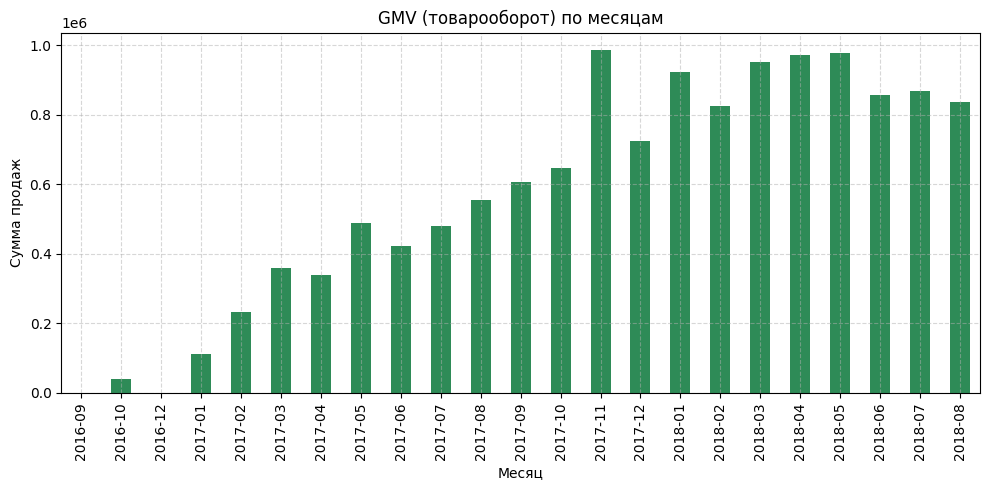

In [10]:
# Рассчет GMV
# Объединение заказов с товарами
df = delivered_orders.merge(olist_order_items, on='order_id', how='inner')
gmv = df.groupby('order_month')['price'].sum()

gmv.plot(kind='bar', figsize=(10,5), color='seagreen')
plt.title('GMV (товарооборот) по месяцам')
plt.ylabel('Сумма продаж')
plt.xlabel('Месяц')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

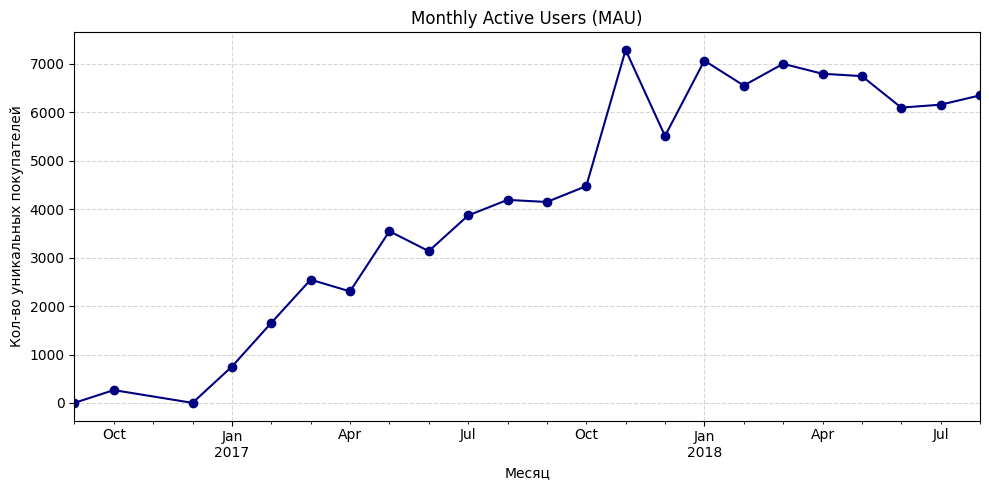

In [11]:
# Рассчет MAU
mau = delivered_orders.groupby('order_month')['customer_id'].nunique()

mau.plot(kind='line', marker='o', figsize=(10,5), color='navy')
plt.title('Monthly Active Users (MAU)')
plt.ylabel('Кол-во уникальных покупателей')
plt.xlabel('Месяц')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

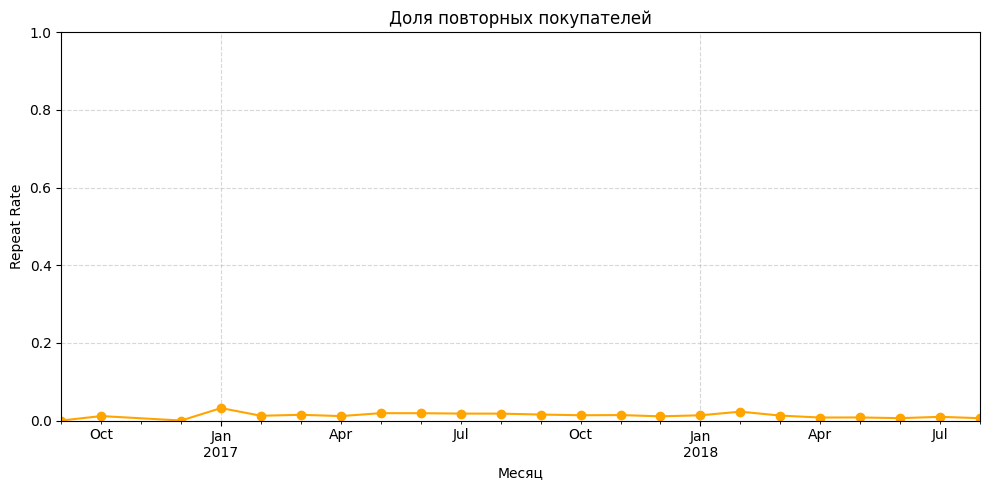

In [12]:
# Рассчет Repurchase Rate
# Кол-во уникальных покупателей с более чем 1 заказом в месяц
orders = delivered_orders.groupby(['customer_unique_id', 'order_month'])['order_id'].nunique().reset_index()
repeat_buyers = orders[orders['order_id'] > 1].groupby('order_month')['customer_unique_id'].nunique()
total_buyers = delivered_orders.groupby('order_month')['customer_unique_id'].nunique()
repeat_rate = (repeat_buyers / total_buyers).fillna(0)

repeat_rate.plot(kind='line', marker='o', figsize=(10,5), color='orange')
plt.title('Доля повторных покупателей')
plt.ylabel('Repeat Rate')
plt.xlabel('Месяц')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

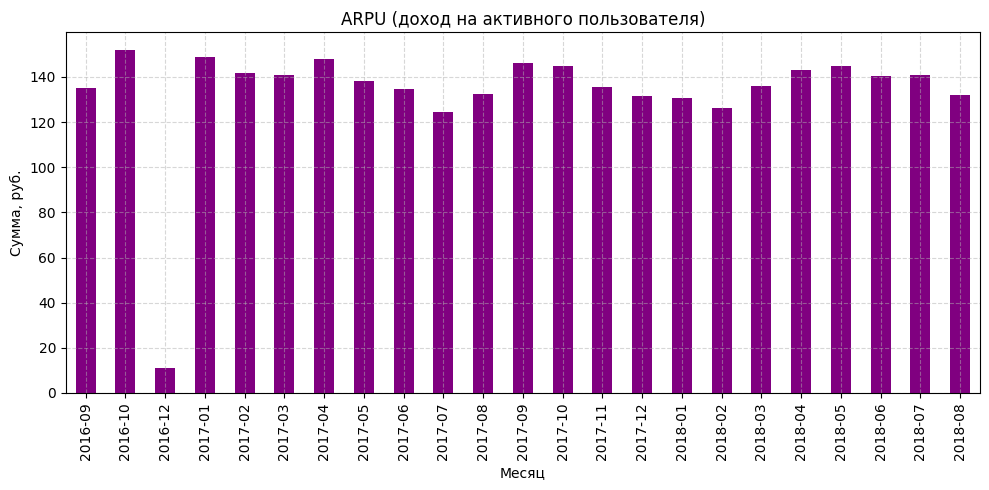

In [13]:
# ARPU
revenue_per_month = df.groupby('order_month')['price'].sum()
arpu = (revenue_per_month / mau).fillna(0)

arpu.plot(kind='bar', figsize=(10,5), color='purple')
plt.title('ARPU (доход на активного пользователя)')
plt.ylabel('Сумма, руб.')
plt.xlabel('Месяц')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.**

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

Для перевода метрики в Impact воспользуйтесь следующей шкалой:
| Impact| 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Значение метрики | 0-50 | 51-150 | 151-350 | 351-750 | 751-1550 | 1551-3150 | 3151-6350 | 6351-12750 | 12751-25550 | 25551-51150 |

Гипотезы

| Гипотеза| Impact | Confidence | Ease | ICE |
| --- | --- | --- | --- | --- |
| Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.	 |  | 8 | 6 |  |
| Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.  |  | 10 | 4 |  |
| Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ. |  | 5 | 9 |  |



In [20]:
# Число отменённых заказов с июня 2017
cancelled = df_full[(df_full['order_status'] == 'canceled') &
                   (df_full['order_purchase_timestamp'] >= '2017-06-01')]

impact1 = cancelled['order_id'].nunique()
print(f'Impact 1-й гипотезы: {impact1}')

Impact 1-й гипотезы: 499


In [21]:
# Число клиентов с хотя бы одним заказом с июня 2017
clients = delivered_orders[delivered_orders['order_purchase_timestamp'] >= '2017-06-01']['customer_unique_id'].nunique()

# Конверсия в повторный заказ ≈ медианный retention 1 мес
impact2 = int(clients * median_retention_month_1)
print(f'Impact 2-й гипотезы: {impact2}')

Impact 2-й гипотезы: 420


In [22]:
# Клиенты с одним заказом
customer_counts = delivered_orders[delivered_orders['order_purchase_timestamp'] >= '2017-06-01'] \
    .groupby('customer_unique_id')['order_id'].nunique()

one_time_buyers = (customer_counts == 1).sum()

# Предположим, конверсия ≈ медианный retention
impact3 = int(one_time_buyers * median_retention_month_1)
print(f'Impact 3-й гипотезы: {impact3}')

Impact 3-й гипотезы: 408


У всех 3-х гипотез одинаковый Impact равный 4

| Гипотеза| Impact | Confidence | Ease | ICE |
| --- | --- | --- | --- | --- |
| Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.	 | 4 | 8 | 6 | 192 |
| Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.  | 4 | 10 | 4 | 160 |
| Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ. | 4 | 5 | 9 | 180 |

1-я гипотеза набрала больше всего баллов по ICE, берем ёё в работу.

**Гипотеза:**
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, 
вследствие чего количество доставленных заказов увеличится.

Цель A/B-теста — оценить влияние исправления бага на ключевые продуктовые метрики.

Формулировка метрик:

**1. Целевая метрика:**
 - Количество доставленных заказов
 - Это основная метрика, напрямую отражающая успех гипотезы. Исправление бага должно повысить эту метрику.

**2. Прокси-метрика:**
 - Retention 1-го месяца
 - Больше доставок → выше удовлетворённость → выше вероятность вернуться и сделать повторный заказ.

**3. Guardrail-метрика:**
 - Среднее время доставки
 - Важно убедиться, что исправление не замедляет процессы и не ухудшает клиентский опыт.

Дополнительно можно отслеживать:
 - Процент отменённых заказов как дополнительный индикатор влияния гипотезы.

Метрики будут собираться с месячной гранулярностью, по контрольной и тестовой группе, до и после внедрения изменений.


### **Задача 6. Вот и подошёл к концу ваш первый этап работы аналитиком в команде маркетплейса. Теперь необходимо поделиться результатами проведённой работы с компанией.**


Сформулируйте выводы о проделанной работе и подготовьте небольшой, но логичный и содержательный отчет для Пети.
Изложите его в комментариях в ipynb-файле или описании мердж-реквеста.

Структура должна выглядеть следующим образом:
- формализация проблемы продукта: что не так и как вы это поняли?

- общие выводы по итогу исследования на основе результатов, полученных в заданиях 1-5;

- рекомендации по продукту.

### Отчёт по исследованию: Повышение пользовательского опыта в маркетплейсе

#### Формализация проблемы

Проблема заключается в низком уровне повторных покупок пользователей.  
Анализ **retention** показал, что:
 - Retention 1-го месяца — **низкий и нестабильный**, особенно у новых пользователей.
 - Пользователи часто **не возвращаются** после первого заказа.
 - Существенная доля заказов **отменяется**, что, вероятно, демотивирует пользователей делать новые покупки.

Из когортного анализа и метрик стало ясно: **продукт не обладает устойчивым product/market fit** — большая часть пользователей быстро «отваливается»

---

#### Общие выводы по результатам анализа

1. **Retention-анализ** показал, что только малая часть пользователей делает повторный заказ — особенно в первый месяц.
2. **Метрики** подтверждают проблему:
 - Высокая доля отмен (cancellation rate).
 - Низкий уровень доставленных заказов (delivered rate).
 - Retention 1-го месяца близок к 0%, что не позволяет говорить о сильной привязке к продукту.
3. **Анализ гипотез по ICE** выявил, что наибольший потенциал улучшения даёт гипотеза:
 - Исправление бага в системе процессинга заказов для уменьшения отмен.
4. **ICE score** этой гипотезы получился наивысшим (192) — благодаря высокому Impact и Confidence.
5. **A/B-тестирование** предложено для валидации гипотезы с метриками:
 - Целевая: Количество доставленных заказов.
 - Прокси: retention 1-го месяца.
 - Guardrail: Среднее время доставки заказа

---

#### Рекомендации по продукту

1. **Реализовать гипотезу №1** — устранение бага в процессинге заказов:
 - Потенциально позволит устранить до 100% отмен по технической причине.
 - Увеличит долю доставленных заказов, создавая позитивный пользовательский опыт.
 - Увеличит Retention, так как успешная доставка напрямую влияет на лояльность.

2. **Запустить A/B-тест** для проверки эффективности:
 - Использовать предложенные метрики для оценки результата.
 - Убедиться, что улучшения не создают новых узких мест (время обработки, рост обращений в поддержку).

3. **Мониторить поведение новых пользователей**:
 - Сосредоточиться на первых 30 днях — этот период критичен для возврата.
 - При необходимости разработать welcome-механику или напоминания.

4. **Продолжать гипотезное тестирование**:
 - Другие гипотезы (например, ускорение отгрузки и альтернативные способы оплаты) могут быть реализованы в дальнейшем, особенно если гипотеза №1 даст значимый рост.
